# Used Car Price Prediction using Linear Regression from Scratch

## Project Introduction

The goal of this project is to build an end-to-end used car price prediction model using multiple linear regression implemented from scratch with NumPy.

The model will predict the selling price of a used car using features such as car age, kilometers driven, fuel type, seller type, transmission type, and ownership history.

Instead of directly using scikit-learn for model training, the core linear regression algorithm will be implemented manually using NumPy, including the cost function, gradient computation, gradient descent, prediction, and evaluation.

This project starts with a simple numeric-feature linear regression model which includes practical machine learning steps such as data loading, missing value handling, feature engineering, train-validation-test split, feature scaling, learning-rate experiments then improves the model using additional categorical features, and finally adds industry-style components such as evaluation, error analysis, regularization, and comparison with scikit-learn.

## Problem Statement

Used car prices depend on multiple factors such as the age of the car, distance driven, fuel type, transmission type, seller type, and ownership history. The aim of this project is to build a regression model that can estimate the selling price of a used car based on these input features.

## Machine Learning Task

This is a supervised machine learning regression problem.

* Input features: Used car details
* Target variable: Selling price
* Algorithm: Multiple Linear Regression from scratch using NumPy
* Evaluation metrics: MAE, RMSE, and R² score


## Import Libraries

In this section, we import the required Python libraries for data handling, numerical computation, and visualization.

In [1]:

import numpy as np
import matplotlib.pyplot as plt


## Dataset Loading

In this section, the used car dataset is loaded using NumPy.

The dataset contains both numerical columns and categorical text columns. Therefore, the data is first loaded with `dtype=str` so that all values can be read safely without automatic type conversion.

The feature columns are stored in `X`, while the target column, `selling_price`, is stored separately in `y`.

At this stage, `X` contains all available input features from the dataset, such as car name, year, kilometers driven, fuel type, seller type, transmission type, and ownership history. The required features for each model version will be selected from `X` later during feature selection and preprocessing.

The target variable `y` contains the selling price of each used car. Numerical columns will be converted into numeric NumPy arrays later before training the linear regression model.


In [2]:
file_path = "../data/car_details.csv"
with open (file_path ,'r') as file:
    header = file.readline().strip().split(",")
    
print(f"columns = {header}")

X = np.genfromtxt(file_path , delimiter="," , skip_header=1 , dtype='str',usecols=[0,1,3,4,5,6,7])
y = np.genfromtxt(file_path , delimiter="," , skip_header=1 , dtype='str',usecols=[2])





columns = ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


## Dataset Overview

In this section, we inspect the loaded dataset to understand its structure before preprocessing.

The feature matrix `X` contains the input columns, while the target vector `y` contains the selling price of each car. We check the number of training examples, number of features, feature names, sample records, and possible missing values.

This step helps verify that the dataset has been loaded correctly and prepares us for feature selection, data cleaning, and numerical conversion in the next stages.


In [3]:

m,n = X.shape
print(f"Number of examples = {m}")
print(f"Number of features = {n}")

feature_names=[]
for i in range(len(header)):
    
    if i == 2:
        continue
    else:
        feature_names.append(header[i])
print(f"Features = {feature_names}")
        


print(f"first 5 examples = {X[0:5:1,:]}\n")
print(f"number of missing values in X ={np.sum(X == "")}")
print(f"number of missing values in y ={np.sum(y == "")}")



Number of examples = 4340
Number of features = 7
Features = ['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']
first 5 examples = [['Maruti 800 AC' '2007' '70000' 'Petrol' 'Individual' 'Manual'
  'First Owner']
 ['Maruti Wagon R LXI Minor' '2007' '50000' 'Petrol' 'Individual'
  'Manual' 'First Owner']
 ['Hyundai Verna 1.6 SX' '2012' '100000' 'Diesel' 'Individual' 'Manual'
  'First Owner']
 ['Datsun RediGO T Option' '2017' '46000' 'Petrol' 'Individual' 'Manual'
  'First Owner']
 ['Honda Amaze VX i-DTEC' '2014' '141000' 'Diesel' 'Individual' 'Manual'
  'Second Owner']]

number of missing values in X =0
number of missing values in y =0


## Data Cleaning and Basic Validation

In this section, we perform basic checks to make sure the dataset is suitable for model training.

The numerical columns are inspected to confirm that they can be converted into numeric values. We also check for unrealistic values such as invalid manufacturing years, negative kilometers driven, or non-positive selling prices.

These checks help ensure that the model is trained on valid and meaningful data.


In [4]:
year = []
for i in range (X[:, 1].shape[0]):
    year.append(int(X[:, 1][i]))

km_driven = []
for i in range (X[:, 2].shape[0]):
    km_driven.append(int(X[:, 2][i]))

selling_price = []
for i in range (y.shape[0]):
    selling_price.append(int(y[i]))


#test
print(f"minimum year ={np.min(year)}")
print(f"maximum year ={np.max(year)}")

print(f"minimum km_driven ={np.min(km_driven)}")
print(f"maximum km_driven ={np.max(km_driven)}")

print(f"minimum selling_price ={np.min(selling_price)}")
print(f"maximum selling_price ={np.max(selling_price)}")

#data_cleaning
yr=[]
for i in range(len(year)):
    if year[i] > 2026:
        yr.append(i)
print(f"number of cars with year > 2026 = {len(yr)}")

yr_2=[]
for i in range(len(year)):
    if year[i] < 1990:
        yr_2.append(i)
print(f"number of cars with year < 1990 = {len(yr_2)}")

km_d=[]
for i in range(len(year)):
    if km_driven[i] < 0:
        km_d.append(i)
print(f"number of cars with km_driven < 0 = {len(km_d)}")

sp=[]
for i in range(len(selling_price)):
    if selling_price[i] <= 0:
        sp.append(i)
print(f"number of cars with selling_price <= 0 = {len(sp)}")

#Outputs confirm that data is clean  
#Checking for duplicates
full_data = np.column_stack((X[:, 0], X[:, 1], y.reshape(-1), X[:, 2], X[:, 3], X[:, 4], X[:, 5], X[:, 6]))


unique_rows, counts = np.unique(full_data, axis=0, return_counts=True)


duplicate_groups = np.sum(counts > 1)
duplicate_rows = np.sum(counts[counts > 1] - 1)

print(f"Number of duplicate groups = {duplicate_groups}")
print(f"Number of duplicate rows = {duplicate_rows}")

#removing duplicates to avoid data leakage
unique_rows, unique_indices = np.unique(full_data, axis=0, return_index=True)
unique_indices = np.sort(unique_indices)

X = X[unique_indices]
y = y[unique_indices]

m_new = X.shape[0]

print(f"Number of duplicate rows removed = {m - m_new}")

#rechecking for duplicates
full_data_cleaned = np.column_stack((X[:, 0], X[:, 1], y.reshape(-1), X[:, 2], X[:, 3], X[:, 4], X[:, 5], X[:, 6]))


unique_rows, counts_cleaned = np.unique(full_data_cleaned, axis=0, return_counts=True)


duplicate_groups_cleaned = np.sum(counts_cleaned > 1)
duplicate_rows_cleaned = np.sum(counts_cleaned[counts_cleaned > 1] - 1)

print(f"Number of duplicate groups after cleaning = {duplicate_groups_cleaned}")
print(f"Number of duplicate rows after cleaning = {duplicate_rows_cleaned}")

#recreating year,km_price & selling price after duplicate removal
year = []
for i in range (X[:, 1].shape[0]):
    year.append(int(X[:, 1][i]))

km_driven = []
for i in range (X[:, 2].shape[0]):
    km_driven.append(int(X[:, 2][i]))

selling_price = []
for i in range (y.shape[0]):
    selling_price.append(int(y[i]))

yr=[]
for i in range(len(year)):
    if year[i] > 2026:
        yr.append(i)
print(f"number of cars with year > 2026 = {len(yr)}")

yr_2=[]
for i in range(len(year)):
    if year[i] < 1990:
        yr_2.append(i)
print(f"number of cars with year < 1990 = {len(yr_2)}")

km_d=[]
for i in range(len(year)):
    if km_driven[i] < 0:
        km_d.append(i)
print(f"number of cars with km_driven < 0 = {len(km_d)}")

sp=[]
for i in range(len(selling_price)):
    if selling_price[i] <= 0:
        sp.append(i)
print(f"number of cars with selling_price <= 0 = {len(sp)}")

minimum year =1992
maximum year =2020
minimum km_driven =1
maximum km_driven =806599
minimum selling_price =20000
maximum selling_price =8900000
number of cars with year > 2026 = 0
number of cars with year < 1990 = 0
number of cars with km_driven < 0 = 0
number of cars with selling_price <= 0 = 0
Number of duplicate groups = 526
Number of duplicate rows = 763
Number of duplicate rows removed = 763
Number of duplicate groups after cleaning = 0
Number of duplicate rows after cleaning = 0
number of cars with year > 2026 = 0
number of cars with year < 1990 = 0
number of cars with km_driven < 0 = 0
number of cars with selling_price <= 0 = 0


## Feature Engineering

In this section, we create a new feature called `car_age` from the manufacturing year of each car.

Using car age is more meaningful than using the raw year value because used car prices usually decrease as the car becomes older. The reference year is taken from the dataset itself so that the age calculation remains consistent with the period represented by the data.

For the first version of the model, we will use only two numerical features: car age and kilometers driven. This creates a simple baseline regression model before adding categorical features later.


In [5]:
referrence_year = np.max(year)
car_age = referrence_year - year

#test
print(f"maximum car age = {np.max(car_age)}")
print(f"minimum car age = {np.min(car_age)}")
print(f"First 5 sellingprices = {selling_price[0:5:1]}")
print(f"First 5 kmdriven = {km_driven[0:5:1]}")

maximum car age = 28
minimum car age = 0
First 5 sellingprices = [60000, 135000, 600000, 250000, 450000]
First 5 kmdriven = [70000, 50000, 100000, 46000, 141000]


## Feature and Target Selection for Model 1

In this section, we select the input features and target variable for the first version of the model.

The first model uses only two numerical features: `car_age` and `km_driven`. This keeps the initial regression model simple and allows us to focus on implementing linear regression from scratch.

The target variable is `selling_price`, which represents the price that the model will learn to predict.


In [6]:
km_driven = np.array(km_driven)
X_model_1 = np.c_[car_age,km_driven]
y_model_1 = np.array(selling_price)

#test
print(f"first 5 examples ={X_model_1[0:5:1,]}\n")
m_1 , n_1 =X_model_1.shape
print(f"Number of examples = {m_1}")
print(f"Number of features = {n_1}")
print(f"shape of target values = {y_model_1.shape}")

first 5 examples =[[    13  70000]
 [    13  50000]
 [     8 100000]
 [     3  46000]
 [     6 141000]]

Number of examples = 3577
Number of features = 2
shape of target values = (3577,)


## Train-Validation-Test Split

In this section, the dataset is divided into training, validation, and test sets.

The training set will be used to learn the model parameters. The validation set will be used for model selection, learning-rate experiments, and tuning decisions. The test set will be kept separate and used only for the final evaluation of the selected model.

The split is performed before feature scaling to avoid data leakage. Scaling parameters such as mean and standard deviation will be calculated only from the training set and then applied to the validation and test sets.


In [7]:
def train_validation_test_split(X,y,test_size,valid_size,random_state=42):
    m=X.shape[0]
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(m)

    test_count=int(test_size*m)
    valid_count = int(valid_size*m)

    test_indices = shuffled_indices[:test_count]
    valid_indices = shuffled_indices[test_count:valid_count + test_count]
    train_indices = shuffled_indices[valid_count + test_count:]


    X_train_raw = X[train_indices]
    y_train =y[train_indices]

    X_val_raw = X[valid_indices]
    y_val=y[valid_indices]

    X_test_raw = X[test_indices]
    y_test = y[test_indices]

    return X_train_raw,y_train,X_val_raw,y_val,X_test_raw,y_test


X_train_raw,y_train,X_val_raw,y_val,X_test_raw,y_test = train_validation_test_split(X_model_1,y_model_1,test_size=0.15,valid_size=0.15,random_state=42)

#test
print(f"X_train_raw shape: {X_train_raw.shape}")
print(f"y_train shape: {y_train.shape}")

print(f"X_val_raw shape: {X_val_raw.shape}")
print(f"y_val shape: {y_val.shape}")

print(f"X_test_raw shape: {X_test_raw.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nTotal examples after split: {X_train_raw.shape[0] + X_val_raw.shape[0] + X_test_raw.shape[0]}")
print(f"Original number of examples: {X_model_1.shape[0]}")



X_train_raw shape: (2505, 2)
y_train shape: (2505,)
X_val_raw shape: (536, 2)
y_val shape: (536,)
X_test_raw shape: (536, 2)
y_test shape: (536,)

Total examples after split: 3577
Original number of examples: 3577


## Feature Scaling

In this section, the input features are scaled using z-score normalization.

The two selected features, car age and kilometers driven, have very different numerical ranges. Feature scaling helps gradient descent converge more smoothly and prevents one feature from dominating the optimization process only because of its larger scale.

The mean and standard deviation are calculated only from the training set. The same training-set scaling parameters are then applied to the validation and test sets to avoid data leakage.


In [8]:
mu = np.mean(X_train_raw , axis=0)
sigma = np.std(X_train_raw, axis=0)

def z_score_norm(x,mu,sigma):
    x_scaled = (x-mu)/sigma

    return x_scaled

X_train = z_score_norm(X_train_raw,mu,sigma)
X_val = z_score_norm(X_val_raw,mu,sigma)
X_test = z_score_norm(X_test_raw,mu,sigma)

#test
print(f"Training mean before scaling={np.mean(X_train_raw,axis=0)}")
print(f"Training std before scaling={np.std(X_train_raw,axis=0)}")

print(f"Training mean after scaling={np.mean(X_train , axis=0)}")
print(f"Training std after scaling={np.std(X_train , axis=0)}")

print(f"Validation shape={X_val.shape}")
print(f"Test shape={X_test.shape}")

Training mean before scaling=[7.08942116e+00 6.98419896e+04]
Training std before scaling=[4.20540331e+00 4.78872555e+04]
Training mean after scaling=[1.47719495e-16 1.68804868e-17]
Training std after scaling=[1. 1.]
Validation shape=(536, 2)
Test shape=(536, 2)


## Baseline Model

In this section, we create a simple baseline model before training linear regression.

The baseline model predicts the mean selling price from the training set for every example. This provides a reference point for evaluating whether the linear regression model is actually learning useful patterns from the input features.

A good machine learning model should perform better than this baseline on the validation and test sets.


## Model Evaluation

In this section, we evaluate the performance of the linear regression model using regression metrics.

The model predictions are compared with the actual selling prices for the training, validation, and test sets.

The evaluation metrics used are:

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* R² Score

MAE measures the average absolute difference between actual and predicted prices. RMSE also measures prediction error but penalizes larger errors more strongly. R² score measures how much variation in the target variable is explained by the model.

These metrics help us compare the linear regression model against the baseline model and understand whether the model has learned useful patterns from the input features.


In [9]:
def mean_absolute_error(y_actual, y_pred):
    error = y_pred - y_actual
    absolute_error = np.abs(error)
    MAE = np.mean(absolute_error)

    return MAE


def root_mean_squared_error(y_actual, y_pred):
    sqrd_error = (y_pred - y_actual)**2
    mean_squared_error =np.mean(sqrd_error)
    RMSE = (mean_squared_error)**0.5

    return RMSE

def r2_score(y_actual, y_pred):
    variation = np.sum((y_actual - np.mean(y_actual))**2)
    sqrd_error = (y_pred - y_actual)**2
    sum_sqrd_errors = np.sum(sqrd_error)
    r2_score = 1-(sum_sqrd_errors/variation)

    return r2_score



MAE_train_baseline = mean_absolute_error(y_train, np.mean(y_train,axis=0))
RMSE_train_baseline = root_mean_squared_error(y_train , np.mean(y_train,axis=0))
r2_score_train_baseline = r2_score(y_train, np.mean(y_train,axis=0)) 

MAE_val_baseline = mean_absolute_error(y_val, np.mean(y_val,axis=0))
RMSE_val_baseline = root_mean_squared_error(y_val , np.mean(y_val,axis=0))
r2_score_val_baseline = r2_score(y_val, np.mean(y_val,axis=0)) 

MAE_test_baseline = mean_absolute_error(y_test, np.mean(y_test,axis=0))
RMSE_test_baseline = root_mean_squared_error(y_test , np.mean(y_test,axis=0))
r2_score_test_baseline = r2_score(y_test, np.mean(y_test,axis=0)) 

print("Baseline Model Evaluation Metrics")
print("---------------------------------")

print(f"Training MAE: {MAE_train_baseline}")
print(f"Validation MAE: {MAE_val_baseline}")
print(f"Test MAE: {MAE_test_baseline}")

print(f"\nTraining RMSE: {RMSE_train_baseline}")
print(f"Validation RMSE: {RMSE_val_baseline}")
print(f"Test RMSE: {RMSE_test_baseline}")

print(f"\nTraining R²: {r2_score_train_baseline}")
print(f"Validation R²: {r2_score_val_baseline}")
print(f"Test R²: {r2_score_test_baseline}")



Baseline Model Evaluation Metrics
---------------------------------
Training MAE: 287568.38149489445
Validation MAE: 315883.8537536199
Test MAE: 303121.8833398307

Training RMSE: 488001.37771785865
Validation RMSE: 504022.1236223086
Test RMSE: 602219.2496228091

Training R²: 0.0
Validation R²: 0.0
Test R²: 0.0


## Linear Regression from Scratch

In this section, we begin building the multiple linear regression model manually using NumPy.

The model will use the scaled input features `X_train`, `X_val`, and `X_test`. The target variable remains the original selling price because the goal is to predict price in rupees.

For each car, the model predicts the selling price using a weighted sum of the input features plus a bias term.

The model equation is:

$$
\hat{y} = w_1x_1 + w_2x_2 + b
$$

For this project:

* $x_1$ represents the scaled car age
* $x_2$ represents the scaled kilometers driven
* $w_1$ is the weight for car age
* $w_2$ is the weight for kilometers driven
* $b$ is the bias term
* $\hat{y}$ is the predicted selling price
* $y$ is the actual selling price

In vector form, the same equation can be written as:

$$
\hat{y} = \mathbf{x} \cdot \mathbf{w} + b
$$

where $\mathbf{x}$ is the input feature vector for one car and $\mathbf{w}$ is the weight vector learned by the model.

The goal of training is to find suitable values of $\mathbf{w}$ and $b$ so that the predicted selling prices are as close as possible to the actual selling prices.

The first step is to implement the cost function, which measures how far the predictions are from the actual prices.


In [10]:
initial_w=np.zeros((2,))
initial_b=0

def compute_cost(x,y,w,b):
    cost=0.0
    m,n=x.shape
    for i in range(m):
        f_wb_i = np.dot(x[i],w) +b
        error = f_wb_i - y[i]
        cost += ((error)**2)
        cost /= (2*m)

        return cost
#test    
print(compute_cost(X_train, y_train, initial_w, initial_b))

    
    


217968644.71077845


## Gradient Computation

In this section, we compute the gradients of the cost function with respect to the model parameters.

The gradient tells us how the cost changes when each parameter changes. During gradient descent, these gradients are used to update the weights and bias in the direction that reduces the cost.

For multiple linear regression, the gradients are calculated as:

$$
\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)x_j^{(i)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)
$$

where:

* $(m)$ is the number of training examples
* $(j)$ represents a feature index
* $(f_{\mathbf{w},b}(\mathbf{x}^{(i)}))$ is the prediction for the (i)-th training example
* $(y^{(i)})$ is the actual selling price for the (i)-th training example
* $(x_j^{(i)})$ is the value of feature (j) for the (i)-th training example

The output of this step will be `dj_dw` and `dj_db`, which will later be used in gradient descent to update the model parameters.


In [11]:
def compute_gradient(X, y, w, b):
    m,n= X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    
    for i in range(m):
        f_wb_i = np.dot(X[i],w) +b
        error = f_wb_i - y[i]

        dj_db += error

        for j in range(n):
            dj_dw[j] += error*X[i,j]

    dj_dw /= m
    dj_db /= m

    return dj_dw,dj_db
    
#test    
dj_dw_test , dj_db_test = compute_gradient(X_train, y_train, initial_w, initial_b)
print(dj_dw_test)
print(dj_db_test)

[210566.89155705  84653.21469519]
-467428.1037924152


## Gradient Descent

In this section, we use gradient descent to learn the model parameters.

Gradient descent repeatedly updates the weights and bias using the gradients calculated from the cost function. The goal is to reduce the cost over multiple iterations so that the model predictions become closer to the actual selling prices.

The parameter update rules are:

$$
w_j = w_j - \alpha \frac{\partial J}{\partial w_j}
$$

$$
b = b - \alpha \frac{\partial J}{\partial b}
$$

where:

* $(w_j)$ is the weight for feature (j)
* $(b)$ is the bias term
* $(\alpha)$ is the learning rate
* $(\frac{\partial J}{\partial w_j})$ is the gradient of the cost with respect to (w_j)
* $(\frac{\partial J}{\partial b})$ is the gradient of the cost with respect to (b)

During training, the cost will be stored after each iteration so that we can visualize whether gradient descent is converging properly.


In [12]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    J_history = []
    w = np.copy(w_in)
    b=b_in
    m,n=X.shape

    for i in range(num_iters):
        dj_dw , dj_db = compute_gradient(X, y,w,b)

        b = b - (alpha*dj_db)
        w = w - (alpha*dj_dw)
    

        cost = compute_cost(X,y,w,b)
        J_history.append(cost)

        print_interval = max(1, num_iters // 10)
        if i % print_interval == 0:
            print(f"iteration : {i} , cost :{J_history[-1]}")
    print(f"Cost after last iteration = {J_history[-1]} and parameters : w={w} and b={b}")

    return w,b,J_history

w_final, b_final , J_history = gradient_descent(X_train, y_train, initial_w, initial_b, 0.01, 1000)  
  



iteration : 0 , cost :214845095.74663538
iteration : 100 , cost :70142632.30294767
iteration : 200 , cost :40094043.607630804
iteration : 300 , cost :31865674.07479123
iteration : 400 , cost :29241029.510554988
iteration : 500 , cost :28340213.281820282
iteration : 600 , cost :28019211.527781326
iteration : 700 , cost :27902086.634954944
iteration : 800 , cost :27858515.14811165
iteration : 900 , cost :27841982.171167936
Cost after last iteration = 27835602.046252403 and parameters : w=[-210739.7793336      827.86083611] and b=467407.9243380995


## Cost Curve Visualization

In this section, we visualize the cost values stored during gradient descent.

The cost curve helps us understand whether gradient descent is converging properly. A decreasing cost curve indicates that the model parameters are being updated in the correct direction and that the model is gradually improving over iterations.


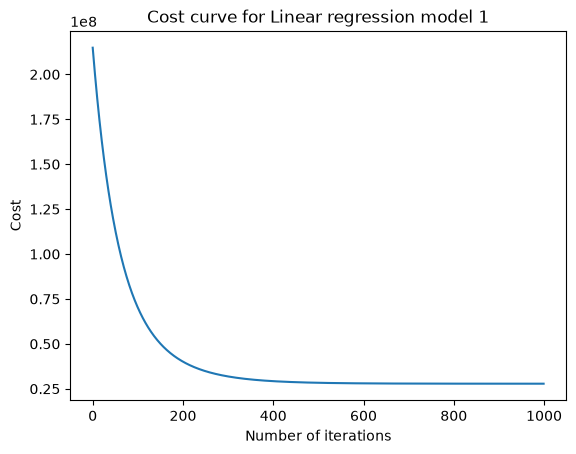

In [13]:
plt.plot(J_history)
plt.xlabel("Number of iterations")
plt.ylabel("Cost")
plt.title("Cost curve for Linear regression model 1")

plt.savefig("../results/learning_curve_model_1.png" , dpi=300 ,bbox_inches = "tight")
plt.show()

## Prediction Function

In this section, we implement a prediction function using the learned model parameters.

The prediction function takes input features, weights, and bias as inputs, and returns the predicted selling prices. These predictions will later be compared with the actual prices to evaluate model performance.


In [14]:
def prediction_function(x,w,b):
    
    prediction = np.dot(x,w) +b
    return prediction

y_train_pred = prediction_function(X_train,w_final,b_final)
y_val_pred = prediction_function(X_val,w_final,b_final)
y_test_pred = prediction_function(X_test,w_final,b_final)

#test
shape = y_train_pred.shape + y_val_pred.shape +  y_test_pred.shape
print(f"First 5 predicted prices = {y_test_pred[0:5:1,]}")
print(f"First 5 actual prices = {y_test[0:5:1,]}")
print(f"shape of predictions = {shape}")

First 5 predicted prices = [721585.65965614 671802.45697485 623540.57249775 721412.78258748
 171221.68477021]
First 5 actual prices = [ 270000  525000  990000 3800000  229999]
shape of predictions = (2505, 536, 536)


## Model 1 Evaluation

In this section, we evaluate the performance of Model 1 using MAE, RMSE, and R² score.

Model 1 uses only "car age" and "kilometers driven" as features . The goal is to check the impact of these features on the model.
 
The model is evaluated on the training, validation, and test sets.

In [15]:

MAE_train_1 = mean_absolute_error(y_train, y_train_pred)
RMSE_train_1 = root_mean_squared_error(y_train , y_train_pred)
r2_score_train_1 = r2_score(y_train, y_train_pred) 

MAE_val_1 = mean_absolute_error(y_val, y_val_pred)
RMSE_val_1 = root_mean_squared_error(y_val , y_val_pred)
r2_score_val_1 = r2_score(y_val, y_val_pred) 

MAE_test_1 = mean_absolute_error(y_test, y_test_pred)
RMSE_test_1 = root_mean_squared_error(y_test , y_test_pred)
r2_score_test_1 = r2_score(y_test, y_test_pred) 

print("Model 1 Evaluation Metrics")
print("--------------------------")

print(f"Training MAE: {MAE_train_1}")
print(f"Validation MAE: {MAE_val_1}")
print(f"Test MAE: {MAE_test_1}")

print(f"\nTraining RMSE: {RMSE_train_1}")
print(f"Validation RMSE: {RMSE_val_1}")
print(f"Test RMSE: {RMSE_test_1}")

print(f"\nTraining R²: {r2_score_train_1}")
print(f"Validation R²: {r2_score_val_1}")
print(f"Test R²: {r2_score_test_1}")



Model 1 Evaluation Metrics
--------------------------
Training MAE: 230265.26815732996
Validation MAE: 253850.55374049128
Test MAE: 238068.21131202002

Training RMSE: 440234.0324458338
Validation RMSE: 452340.6439171973
Test RMSE: 555811.0820610188

Training R²: 0.18618605119210196
Validation R²: 0.1945621693545988
Test R²: 0.14818528799522213


### Model 1 Evaluation Summary

The first linear regression model uses only two numerical features: car age and kilometers driven.

The model performs better than the baseline model based on MAE. This shows that the selected features contain useful information for predicting used car prices.

However, the R² score is relatively low, which indicates that car age and kilometers driven alone explain only a limited part of the variation in selling price. Used car prices are also influenced by other factors such as fuel type, transmission type, seller type, ownership history, and brand.

Therefore, Model 1 is useful as a simple baseline regression model, but further improvement is needed by adding more relevant features and performing learning-rate experiments.


## Learning Rate Experiments

In this section, we train the linear regression model using different learning rates.

The learning rate controls the size of each parameter update during gradient descent. A very small learning rate may make training slow, while a very large learning rate may cause the cost to increase or diverge.

By comparing different learning rates, we can choose a stable value that allows the cost to decrease efficiently.


In [ ]:
# #learning rate = 0.001
# print("learning rate = 0.001")
# print("-----------------------")
# w_final_1, b_final_1 , J_history_1 = gradient_descent(X_train, y_train, initial_w, initial_b, 0.001, 1000) 

# #learning rate = 0.01
# print("learning rate = 0.01")
# print("----------------------")
# w_final_2, b_final_2 , J_history_2 = gradient_descent(X_train, y_train, initial_w, initial_b, 0.01, 1000) 

# #learning rate = 0.03
# print("learning rate = 0.03")
# print("----------------------")
# w_final_3, b_final_3 , J_history_3 = gradient_descent(X_train, y_train, initial_w, initial_b, 0.03, 1000) 

#learning rate = 0.1
print("learning rate = 0.1")
print("---------------------")
w_final_4, b_final_4 , J_history_4 = gradient_descent(X_train, y_train, initial_w, initial_b, 0.1, 1000) 

learning rate = 0.1
---------------------
iteration : 0 , cost :187747565.63837367
iteration : 100 , cost :27833944.99648769
iteration : 200 , cost :27831097.1875239
iteration : 300 , cost :27831094.55786369
iteration : 400 , cost :27831094.552175745
iteration : 500 , cost :27831094.552163232


### Learning Rate Experiment Summary

Several learning rates were tested to understand how they affect the convergence of gradient descent.

The learning rate `0.001` decreased the cost steadily but was too slow. The learning rate `0.01` converged much better, but still required more iterations. The learning rates `0.03` and `0.1` reached almost the same final cost, but `0.1` converged faster without causing divergence.

Based on these results, `alpha = 0.1` is selected as the learning rate for Model 1.


In [ ]:

y_train_pred = prediction_function(X_train,w_final_4,b_final_4)
y_val_pred = prediction_function(X_val,w_final_4,b_final_4)
y_test_pred = prediction_function(X_test,w_final_4,b_final_4)


MAE_train_1 = mean_absolute_error(y_train, y_train_pred)
RMSE_train_1 = root_mean_squared_error(y_train , y_train_pred)
r2_score_train_1 = r2_score(y_train, y_train_pred) 

MAE_val_1 = mean_absolute_error(y_val, y_val_pred)
RMSE_val_1 = root_mean_squared_error(y_val , y_val_pred)
r2_score_val_1 = r2_score(y_val, y_val_pred) 

MAE_test_1 = mean_absolute_error(y_test, y_test_pred)
RMSE_test_1 = root_mean_squared_error(y_test , y_test_pred)
r2_score_test_1 = r2_score(y_test, y_test_pred) 

print("Model 1 Evaluation Metrics after learning rate selection")
print("--------------------------------------------------------")

print(f"Training MAE: {MAE_train_1}")
print(f"Validation MAE: {MAE_val_1}")
print(f"Test MAE: {MAE_test_1}")

print(f"\nTraining RMSE: {RMSE_train_1}")
print(f"Validation RMSE: {RMSE_val_1}")
print(f"Test RMSE: {RMSE_test_1}")

print(f"\nTraining R²: {r2_score_train_1}")
print(f"Validation R²: {r2_score_val_1}")
print(f"Test R²: {r2_score_test_1}")


Model 1 Evaluation Metrics after learning rate selection
--------------------------------------------------------
Training MAE: 230280.4612220032
Validation MAE: 253879.1781573795
Test MAE: 238105.06464598814

Training RMSE: 440233.92975046864
Validation RMSE: 452340.6754513469
Test RMSE: 555823.7470858203

Training R²: 0.18618643087610964
Validation R²: 0.19456205705517005
Test R²: 0.1481464676920088


### Final Model 1 Summary

After testing multiple learning rates, `alpha = 0.1` was selected because it reached the lowest cost quickly without divergence.

The final Model 1 uses two numerical features: car age and kilometers driven. Compared with the baseline model, Model 1 achieves lower MAE on the training, validation, and test sets, showing that these features provide useful predictive information.

However, the R² score remains relatively low. This indicates that car age and kilometers driven alone explain only a limited portion of the variation in used car prices. Other features such as fuel type, transmission type, seller type, ownership history, and brand are likely important for improving prediction performance.

Therefore, Model 1 will be treated as a simple numerical-feature regression baseline before building an improved model with additional features.


## Actual vs Predicted Plot for Model 1

In this section, we visualize the relationship between the actual selling prices and the predicted selling prices for Model 1.

The plot helps us understand how close the model predictions are to the true values. If the model predicts well, the points should lie close to the diagonal reference line where actual price equals predicted price.

Since Model 1 uses only car age and kilometers driven, some prediction errors are expected. This plot will help us visually inspect the limitations of the simple numerical-feature model.


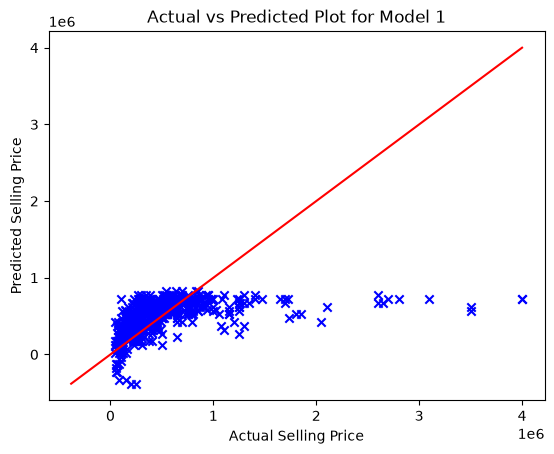

In [ ]:
plt.scatter(y_val, y_val_pred, marker="x", c="blue")

min_price = min(np.min(y_val), np.min(y_val_pred))
max_price = max(np.max(y_val), np.max(y_val_pred))

plt.plot([min_price, max_price], [min_price, max_price], c="red")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Plot for Model 1")

plt.savefig("../results/actual_vs_predicted_plot_model_1.png", dpi=300, bbox_inches="tight")
plt.show()

The actual vs predicted plot shows that Model 1 captures some general pricing pattern, but many points are far from the diagonal reference line.

The model performs better for lower-priced cars, but it tends to underpredict higher-priced cars. This suggests that car age and kilometers driven alone are not enough to explain the full variation in used car prices.

This visual result is consistent with the low R² score observed during evaluation.


## Residual Analysis for Model 1

In this section, we analyze the residuals of Model 1 on the validation set.

A residual is the difference between the actual selling price and the predicted selling price:

$$
\text{Residual} = y - \hat{y}
$$

where:

* $(y)$ is the actual selling price
* $(\hat{y})$ is the predicted selling price

A positive residual means the model underpredicted the car price, while a negative residual means the model overpredicted the car price.

The residual plot helps us understand whether the model errors are randomly distributed or whether there is a visible pattern. Ideally, residuals should be scattered around zero without a strong pattern.

Since Model 1 uses only car age and kilometers driven, this analysis helps us identify whether the model is missing important information from other features.


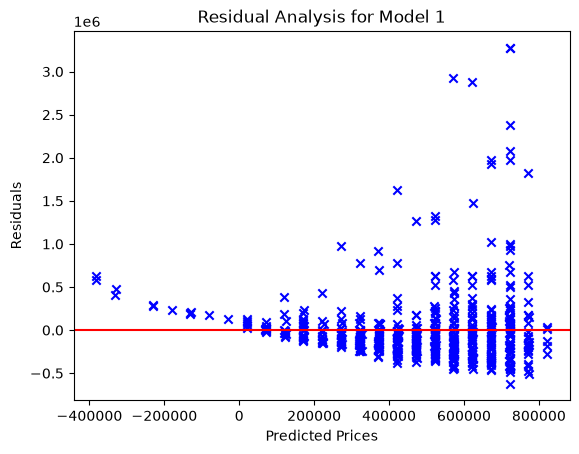

In [ ]:
residuals_model_1 = y_val - y_val_pred
plt.scatter(y_val_pred,residuals_model_1, marker="x", c="blue")


plt.axhline(y=0, c="red")

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Analysis for Model 1")

plt.savefig("../results/residual_analysis_model_1.png", dpi=300, bbox_inches="tight")
plt.show()

### Residual Analysis Summary

The residual plot shows that the errors are not completely randomly distributed around zero.

Several cars have large positive residuals, which means the model underpredicts their selling prices. This is especially visible for higher-priced cars.

This suggests that Model 1 is missing important information. Since the model uses only car age and kilometers driven, it cannot fully capture price differences caused by features such as fuel type, transmission type, seller type, ownership history, and brand.

Therefore, the next step is to build an improved model by adding categorical features.

## Model 2: Adding Categorical Features

Model 1 used only two numerical features: car age and kilometers driven. Although it performed better than the baseline model, the R² score remained low, showing that these two features alone cannot explain used car prices well.

In this section, we build an improved model by adding categorical features such as fuel type, seller type, transmission type, and ownership history.

These features are important because used car prices can vary significantly depending on the type of fuel, whether the car is manual or automatic, the type of seller, and how many previous owners the car had.

The goal of Model 2 is to improve prediction performance while still building the regression model manually using NumPy.


In [ ]:
#checking for unique values in categorical featueres for model 2
categorical_features = {
    "fuel": X[:, 3],
    "seller_type": X[:, 4],
    "transmission": X[:, 5],
    "owner": X[:, 6]
}

for feature_name, feature_values in categorical_features.items():
    unique_values, counts = np.unique(feature_values, return_counts=True)
    
    print(f"\n{feature_name}")
    print("-" * len(feature_name))
    
    for value, count in zip(unique_values, counts):
        print(f"{value}: {count}")



fuel
----
CNG: 37
Diesel: 1800
Electric: 1
LPG: 22
Petrol: 1717

seller_type
-----------
Dealer: 712
Individual: 2832
Trustmark Dealer: 33

transmission
------------
Automatic: 312
Manual: 3265

owner
-----
First Owner: 2218
Fourth & Above Owner: 75
Second Owner: 978
Test Drive Car: 17
Third Owner: 289


## Categorical Feature Inspection

Before using categorical features in a linear regression model, we inspect the unique values present in each categorical column.

Linear regression cannot directly use text values such as fuel type or transmission type. These values must be converted into numerical form before model training.

The categorical features selected for Model 2 are fuel type, seller type, transmission type, and ownership history.


In [ ]:
fuel = np.array(X[:, 3])
seller_type = np.array(X[:, 4])
transmission = np.array(X[:, 5])
owner = np.array(X[:, 6])

X_model_2_raw = np.c_[car_age,km_driven,fuel,seller_type,transmission,owner]
y_model_2 = np.array(selling_price)

#test
print(X_model_2_raw.shape)
print(y_model_2.shape)



(3577, 6)
(3577,)


## Feature Selection for Model 2

For Model 2, we use both numerical and categorical features.

The numerical features are car age and kilometers driven. The categorical features are fuel type, seller type, transmission type, and ownership history.

The target variable remains selling price.

At this stage, the feature matrix contains both numerical and text-based values. The categorical values will be encoded before model training.


In [ ]:
#Train-validation-test split for Model 2

X_train_raw_model_2,y_train_model_2,X_val_raw_model_2,y_val_model_2,X_test_raw_model_2,y_test_model_2 = train_validation_test_split(X_model_2_raw,y_model_2,test_size=0.15,valid_size=0.15,random_state=42)

#test
print(f"X_train_raw shape: {X_train_raw_model_2.shape}")
print(f"y_train shape: {y_train_model_2.shape}")

print(f"X_val_raw shape: {X_val_raw_model_2.shape}")
print(f"y_val shape: {y_val_model_2.shape}")

print(f"X_test_raw shape: {X_test_raw_model_2.shape}")
print(f"y_test shape: {y_test_model_2.shape}")

print(f"\nTotal examples after split: {X_train_raw_model_2.shape[0] + X_val_raw_model_2.shape[0] + X_test_raw_model_2.shape[0]}")
print(f"Original number of examples: {X_model_2_raw.shape[0]}")

X_train_raw shape: (2505, 6)
y_train shape: (2505,)
X_val_raw shape: (536, 6)
y_val shape: (536,)
X_test_raw shape: (536, 6)
y_test shape: (536,)

Total examples after split: 3577
Original number of examples: 3577


## Separating Numerical and Categorical Features

In this step, the raw Model 2 feature matrix is separated into numerical and categorical parts.

The first two columns contain numerical features: car age and kilometers driven. These features will be scaled using z-score normalization.

The remaining columns contain categorical features: fuel type, seller type, transmission type, and ownership history. These features will be encoded into numerical columns before model training.

Separating the features makes the preprocessing workflow cleaner and helps us apply the correct transformation to each feature type.


In [ ]:


X_train_num_raw_2 = np.c_[X_train_raw_model_2[:,0],X_train_raw_model_2[:,1]].astype(float)
X_val_num_raw_2 = np.c_[X_val_raw_model_2[:,0],X_val_raw_model_2[:,1]].astype(float)
X_test_num_raw_2 = np.c_[X_test_raw_model_2[:,0],X_test_raw_model_2[:,1]].astype(float)

X_train_cat_raw_2 = np.c_[X_train_raw_model_2[:,2],X_train_raw_model_2[:,3],X_train_raw_model_2[:,4],X_train_raw_model_2[:,5]]
X_val_cat_raw_2 = np.c_[X_val_raw_model_2[:,2],X_val_raw_model_2[:,3],X_val_raw_model_2[:,4],X_val_raw_model_2[:,5]]
X_test_cat_raw_2  = np.c_[X_test_raw_model_2[:,2],X_test_raw_model_2[:,3],X_test_raw_model_2[:,4],X_test_raw_model_2[:,5]]

## Encoding and Scaling Strategy

Model 2 contains both numerical and categorical features.

The numerical features will be scaled using z-score normalization. The mean and standard deviation will be calculated only from the training set and then applied to the validation and test sets.

The categorical features will be converted into numerical columns using one-hot encoding. The encoding categories will be learned from the training set and then applied to the validation and test sets.

This keeps the preprocessing workflow consistent and avoids data leakage.


In [ ]:
def one_hot_encode(train_column, column_to_encode, drop_first=True):
    categories = np.unique(train_column)

    if drop_first:
        categories_to_encode = categories[1:]
    else:
        categories_to_encode = categories

    encoded_columns = []

    for category in categories_to_encode:
        encoded_column = (column_to_encode == category).astype(int)
        encoded_columns.append(encoded_column)

    if len(encoded_columns) == 0:
        encoded_matrix = np.zeros((column_to_encode.shape[0], 0), dtype=int)
    else:
        encoded_matrix = np.column_stack(encoded_columns)

    return encoded_matrix, categories_to_encode

X_train_fuel_2, fuel_categories_2 = one_hot_encode(
    X_train_cat_raw_2[:, 0],
    X_train_cat_raw_2[:, 0],
    drop_first=True
)

X_val_fuel_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 0],
    X_val_cat_raw_2[:, 0],
    drop_first=True
)

X_test_fuel_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 0],
    X_test_cat_raw_2[:, 0],
    drop_first=True
)
# Seller type
X_train_seller_2, seller_categories_2 = one_hot_encode(
    X_train_cat_raw_2[:, 1],
    X_train_cat_raw_2[:, 1],
    drop_first=True
)

X_val_seller_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 1],
    X_val_cat_raw_2[:, 1],
    drop_first=True
)

X_test_seller_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 1],
    X_test_cat_raw_2[:, 1],
    drop_first=True
)


# Transmission
X_train_transmission_2, transmission_categories_2 = one_hot_encode(
    X_train_cat_raw_2[:, 2],
    X_train_cat_raw_2[:, 2],
    drop_first=True
)

X_val_transmission_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 2],
    X_val_cat_raw_2[:, 2],
    drop_first=True
)

X_test_transmission_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 2],
    X_test_cat_raw_2[:, 2],
    drop_first=True
)


# Owner
X_train_owner_2, owner_categories_2 = one_hot_encode(
    X_train_cat_raw_2[:, 3],
    X_train_cat_raw_2[:, 3],
    drop_first=True
)

X_val_owner_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 3],
    X_val_cat_raw_2[:, 3],
    drop_first=True
)

X_test_owner_2, _ = one_hot_encode(
    X_train_cat_raw_2[:, 3],
    X_test_cat_raw_2[:, 3],
    drop_first=True
)

# Now combining the encoded categorical columns:

X_train_cat_2 = np.c_[
    X_train_fuel_2,
    X_train_seller_2,
    X_train_transmission_2,
    X_train_owner_2
]

X_val_cat_2 = np.c_[
    X_val_fuel_2,
    X_val_seller_2,
    X_val_transmission_2,
    X_val_owner_2
]

X_test_cat_2 = np.c_[
    X_test_fuel_2,
    X_test_seller_2,
    X_test_transmission_2,
    X_test_owner_2
]

#test

print(f"Fuel encoded categories: {fuel_categories_2}")
print(f"Seller type encoded categories: {seller_categories_2}")
print(f"Transmission encoded categories: {transmission_categories_2}")
print(f"Owner encoded categories: {owner_categories_2}")

print(f"\nX_train_cat_2 shape: {X_train_cat_2.shape}")
print(f"X_val_cat_2 shape: {X_val_cat_2.shape}")
print(f"X_test_cat_2 shape: {X_test_cat_2.shape}")

print(f"\nFirst 5 encoded categorical rows:\n{X_train_cat_2[0:5]}")





Fuel encoded categories: ['Diesel' 'LPG' 'Petrol']
Seller type encoded categories: ['Individual' 'Trustmark Dealer']
Transmission encoded categories: ['Manual']
Owner encoded categories: ['Fourth & Above Owner' 'Second Owner' 'Test Drive Car' 'Third Owner']

X_train_cat_2 shape: (2505, 10)
X_val_cat_2 shape: (536, 10)
X_test_cat_2 shape: (536, 10)

First 5 encoded categorical rows:
[[1 0 0 1 0 1 0 0 0 0]
 [1 0 0 0 0 1 0 1 0 0]
 [0 0 1 1 0 1 0 0 0 1]
 [0 0 1 1 0 1 0 0 0 0]
 [1 0 0 1 0 1 0 0 0 1]]


In [ ]:
# Scale numerical features
mu_2=np.mean(X_train_num_raw_2)
sigma_2=np.std(X_test_num_raw_2)


X_train_num_2 = z_score_norm(X_train_raw,mu_2,sigma_2)
X_val_num_2 = z_score_norm(X_val_raw,mu_2,sigma_2)
X_test_num_2 = z_score_norm(X_test_raw,mu_2,sigma_2)




In [ ]:
#Combining numerical and categorical features
X_train_2=np.c_[X_train_num_2,X_train_cat_2]
X_val_2=np.c_[X_val_num_2,X_val_cat_2]
X_test_2=np.c_[X_test_num_2,X_test_cat_2]

#test
print(X_train_2.shape)
print(X_val_2.shape)
print(X_test_2.shape)


(2505, 12)
(536, 12)
(536, 12)


## Training Model 2

In this section, we train the second linear regression model using both numerical and encoded categorical features.

The same cost function, gradient computation, gradient descent function, and prediction function from Model 1 are reused. Only the feature matrix changes.

Model 2 is expected to perform better than Model 1 because it uses additional information about fuel type, seller type, transmission type, and ownership history.


In [ ]:
initial_w_2 = np.zeros(X_train_2.shape[1])
initial_b_2 = 0

alpha = 0.1
num_iters = 1000

compute_cost(X_train_2,y_train,initial_w_2,initial_b_2)
dj_dw_model_2,dj_db_model_2= compute_gradient(X_train_2,y_train,initial_w_2,initial_b_2)
w_final_model_2,b_final_model_2,J_history_model_2=gradient_descent(X_train_2,y_train,initial_w_2,initial_b_2,alpha,num_iters)
y_train_pred_model_2 = prediction_function(X_train_2,w_final_model_2,b_final_model_2)
y_val_pred_model_2 = prediction_function(X_val_2,w_final_model_2,b_final_model_2)
y_test_pred_model_2 = prediction_function(X_test_2,w_final_model_2,b_final_model_2)

#test
print("Model 2 Prediction Test")
print("-" * 25)

print(f"X_train_2 shape: {X_train_2.shape}")
print(f"w_final_model_2 shape: {w_final_model_2.shape}")

print(f"\ny_train_pred_2 shape: {y_train_pred_model_2.shape}")
print(f"y_val_pred_2 shape: {y_val_pred_model_2.shape}")
print(f"y_test_pred_2 shape: {y_test_pred_model_2.shape}")

print(f"\nFirst 5 predicted training prices:\n{y_train_pred_model_2[:5]}")
print(f"\nFirst 5 actual training prices:\n{y_train_model_2[:5]}")

print(f"\nAny NaN in train predictions: {np.isnan(y_train_pred_model_2).any()}")
print(f"Any NaN in validation predictions: {np.isnan(y_val_pred_model_2).any()}")
print(f"Any NaN in test predictions: {np.isnan(y_test_pred_model_2).any()}")

iteration : 0 , cost :153099731.36634463
iteration : 100 , cost :20088416.896502886
iteration : 200 , cost :22245799.96754843
iteration : 300 , cost :23739268.185488824
iteration : 400 , cost :24575834.873668157
iteration : 500 , cost :25053626.1907523
iteration : 600 , cost :25331506.070813052
iteration : 700 , cost :25495789.10565664
iteration : 800 , cost :25595004.78338532
iteration : 900 , cost :25656904.92723567
Cost after last iteration = 25697109.004653912 and parameters : w=[-514567.63799913  -80135.55284878  413258.97441696   45007.89658577
   91169.45143233  -43572.62061398   57567.60742994 -765343.30929244
 -189076.82966174 -136455.91305021  129518.88054718 -171655.49811799] and b=669703.1899210006
Model 2 Prediction Test
-------------------------
X_train_2 shape: (2505, 12)
w_final_model_2 shape: (12,)

y_train_pred_2 shape: (2505,)
y_val_pred_2 shape: (536,)
y_test_pred_2 shape: (536,)

First 5 predicted training prices:
[686191.92633322 558930.59672336  77985.30280937 39

## Model 2 Evaluation

In this section, we evaluate the performance of Model 2 using MAE, RMSE, and R² score.

Model 2 uses both numerical features and encoded categorical features. The goal is to check whether adding fuel type, seller type, transmission type, and ownership history improves prediction performance compared with Model 1.

The model is evaluated on the training, validation, and test sets.


Model 2 Evaluation Metrics
--------------------------
Training MAE: 222274.91043093876
Validation MAE: 227631.90654739036
Test MAE: 228769.21317296123

Training RMSE: 384265.0537424127
Validation RMSE: 373073.33044307906
Test RMSE: 488389.8119074634

Training R²: 0.37996003347507934
Validation R²: 0.45211525472808134
Test R²: 0.34230593218855854


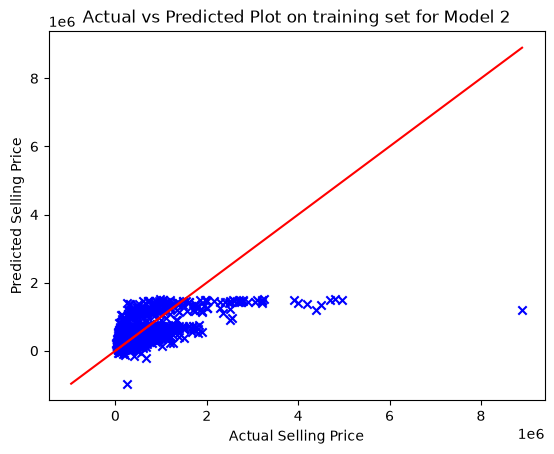

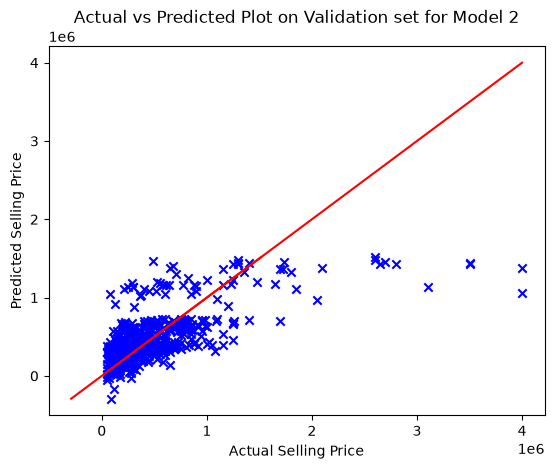

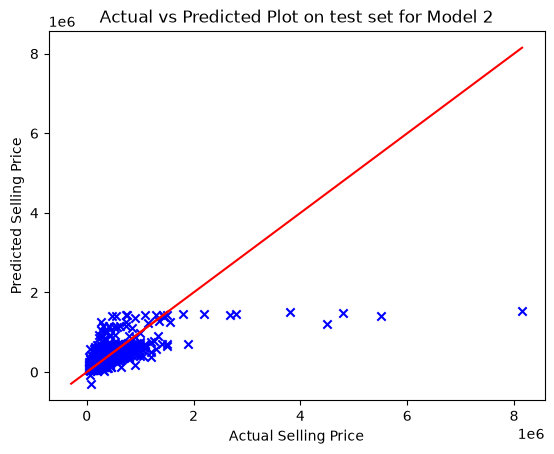

In [ ]:
MAE_train_2 = mean_absolute_error(y_train, y_train_pred_model_2)
RMSE_train_2 = root_mean_squared_error(y_train , y_train_pred_model_2)
r2_score_train_2 = r2_score(y_train, y_train_pred_model_2) 

MAE_val_2 = mean_absolute_error(y_val, y_val_pred_model_2)
RMSE_val_2 = root_mean_squared_error(y_val , y_val_pred_model_2)
r2_score_val_2 = r2_score(y_val, y_val_pred_model_2) 

MAE_test_2 = mean_absolute_error(y_test, y_test_pred_model_2)
RMSE_test_2 = root_mean_squared_error(y_test , y_test_pred_model_2)
r2_score_test_2 = r2_score(y_test, y_test_pred_model_2) 

print("Model 2 Evaluation Metrics")
print("--------------------------")

print(f"Training MAE: {MAE_train_2}")
print(f"Validation MAE: {MAE_val_2}")
print(f"Test MAE: {MAE_test_2}")

print(f"\nTraining RMSE: {RMSE_train_2}")
print(f"Validation RMSE: {RMSE_val_2}")
print(f"Test RMSE: {RMSE_test_2}")

print(f"\nTraining R²: {r2_score_train_2}")
print(f"Validation R²: {r2_score_val_2}")
print(f"Test R²: {r2_score_test_2}")


#actual_vs_predicted plot on training set for Model 2
plt.scatter(y_train_model_2,y_train_pred_model_2,c="blue",marker="x")

min_price = [np.min(y_train_model_2),np.min(y_train_pred_model_2)]
max_price = [np.max(y_train_model_2),np.max(y_train_pred_model_2)]

plt.plot([max_price,min_price],[max_price,min_price], c="red")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Plot on training set for Model 2")

plt.savefig("../results/actual_vs_predicted_plot_train_model_2.png", dpi=300, bbox_inches="tight")
plt.show()


#actual_vs_predicted plot on validation set for Model 2
plt.scatter(y_val_model_2,y_val_pred_model_2,c="blue",marker="x")

min_price = [np.min(y_val_model_2),np.min(y_val_pred_model_2)]
max_price = [np.max(y_val_model_2),np.max(y_val_pred_model_2)]

plt.plot([max_price,min_price],[max_price,min_price], c="red")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Plot on Validation set for Model 2")

plt.savefig("../results/actual_vs_predicted_plot_val_model_2.png", dpi=300, bbox_inches="tight")
plt.show()


#actual_vs_predicted plot on testing set for Model 2
plt.scatter(y_test_model_2,y_test_pred_model_2,c="blue",marker="x")

min_price = [np.min(y_test_model_2),np.min(y_test_pred_model_2)]
max_price = [np.max(y_test_model_2),np.max(y_test_pred_model_2)]

plt.plot([max_price,min_price],[max_price,min_price], c="red")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Plot on test set for Model 2")

plt.savefig("../results/actual_vs_predicted_plot_test_model_2.png", dpi=300, bbox_inches="tight")
plt.show()




### Model 2 Actual vs Predicted Plot Summary

The actual vs predicted plots show that Model 2 captures some general relationship between the selected features and selling price.

Compared with Model 1, Model 2 uses additional categorical information such as fuel type, seller type, transmission type, and ownership history. However, many predictions are still far from the diagonal reference line.

The model performs better for lower-priced cars, but it continues to underpredict several high-priced cars. This suggests that important pricing information is still missing, especially details related to the car brand and model name.

Therefore, Model 2 improves the feature set but is still not sufficient for highly accurate price prediction.


## Residual Analysis for Model 2

In this section, we apply residual analysis to Model 2 using the validation set.

The same residual definition used earlier is followed:

$$
\text{Residual} = y - \hat{y}
$$

This plot helps us check whether adding categorical features reduced the prediction errors or whether clear error patterns still remain.


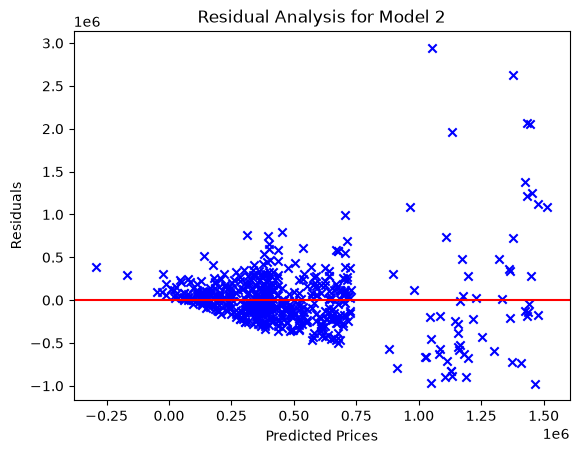

In [ ]:
residuals_model_2 = y_val_model_2 - y_val_pred_model_2
plt.scatter(y_val_pred_model_2,residuals_model_2, marker="x", c="blue")


plt.axhline(y=0, c="red")

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Analysis for Model 2")

plt.savefig("../results/residual_analysis_model_2.png", dpi=300, bbox_inches="tight")
plt.show()

## Baseline vs Model 1 vs Model 2 Comparison

In this section, we compare the performance of the baseline model, Model 1, and Model 2.

The baseline model predicts the mean selling price for every car. Model 1 uses only numerical features, while Model 2 uses both numerical and encoded categorical features.

The comparison helps us understand whether each improvement in the feature set actually improves prediction performance.


In [ ]:
print("MODEL COMPARISION")
print("-" * 115)

print(
    f"{'Model':<18} "
    f"{'Validation MAE':<18} "
    f"{'Test MAE':<18} "
    f"{'Validation r2':<18} "
    f"{'Test r2':<18} "
)

print("-" * 115)

print(
    f"{'Baseline':<18} "
    f"{MAE_val_baseline:<18} "
    f"{MAE_test_baseline:<18} "
    f"{r2_score_val_baseline:<18} "
    f"{r2_score_test_baseline:<18} "
)

print("-" * 115)

print(
    f"{'Model 1':<18} "
    f"{MAE_val_1:<18} "
    f"{MAE_test_1:<18} "
    f"{r2_score_val_1:<18} "
    f"{r2_score_test_1:<18} "
)

print("-" * 115)

print(
    f"{'Model 2':<18} "
    f"{MAE_val_2:<18} "
    f"{MAE_test_2:<18} "
    f"{r2_score_val_2:<18} "
    f"{r2_score_test_2:<18} "
)



MODEL COMPARISION
-------------------------------------------------------------------------------------------------------------------
Model              Validation MAE     Test MAE           Validation r2      Test r2            
-------------------------------------------------------------------------------------------------------------------
Baseline           315883.8537536199  303121.8833398307  0.0                0.0                
-------------------------------------------------------------------------------------------------------------------
Model 1            253879.1781573795  238105.06464598814 0.19456205705517005 0.1481464676920088 
-------------------------------------------------------------------------------------------------------------------
Model 2            227631.90654739036 228769.21317296123 0.45211525472808134 0.34230593218855854 


### Model Comparison Summary

The comparison shows that both linear regression models perform better than the baseline model.

Model 1 reduces the prediction error by using car age and kilometers driven as numerical features. However, its R² score remains low, showing that these two features alone cannot explain used car prices well.

Model 2 performs better than Model 1. It achieves a lower MAE and a higher R² score on both the validation and test sets. This shows that categorical features such as fuel type, seller type, transmission type, and ownership history provide useful information for predicting used car prices.

However, the model still makes noticeable errors, especially for expensive cars. This suggests that more important information, such as car brand and model name, may still be missing.


## Model 3: Regularized Linear Regression

In this section, we build a regularized linear regression model.

Model 2 uses both numerical and encoded categorical features, which increases the number of input features. When the number of features increases, regularization can help control the size of the model weights and reduce the risk of overfitting.

Regularization adds a penalty term to the cost function. This penalty discourages very large weight values and helps the model generalize better to unseen data.

Only the weights are regularized. The bias term is not regularized.


In [ ]:
#regularized cost function

initial_w=np.zeros((12,))
initial_b=0

def compute_cost_reg(x,y,w,b,lambda_):
    reg =0
    cost=0.0
    m,n=x.shape
    for i in range(m):
        f_wb_i = np.dot(x[i],w) +b
        error = f_wb_i - y[i]
        cost += ((error)**2)
        cost /= (2*m)

        for j in range(n):
            reg+=(lambda_/m)*w[j]**2

        cost += reg
        return cost
    
#regularized gradient function
def compute_gradient_reg(X, y, w, b,lambda_):   
    dj_dw,dj_db =compute_gradient(X, y, w, b)
    dj_db = np.copy(dj_db)
    m,n=X.shape
    for i in range(n):
        dj_dw[i] += (lambda_/m)*w[i]
    
    return dj_dw,dj_db

#regularized gradient function
def gradient_descent_reg(X, y, w_in, b_in, alpha, num_iters,lambda_):
    J_history = []
    w = np.copy(w_in)
    b=b_in
    m,n=X.shape

    for i in range(num_iters):
        dj_dw , dj_db = compute_gradient_reg(X, y,w,b,lambda_)

        b = b - (alpha*dj_db)
        w = w - (alpha*dj_dw)
    

        cost = compute_cost_reg(X,y,w,b,lambda_)
        J_history.append(cost)

        print_interval = max(1, num_iters // 10)
        if i % print_interval == 0:
            print(f"iteration : {i} , cost :{J_history[-1]}")
    print(f"Cost after last iteration = {J_history[-1]} and parameters : w={w} and b={b}")

    return w,b,J_history
    

### Best Lambda Selection

The validation performance of the regularized linear regression model is evaluated for different values of the regularization parameter, $\lambda$.

For each value of $\lambda$, the model is trained on the training set and evaluated on the validation set using MAE, RMSE, and R² score.

The lambda value that produces the lowest validation error while maintaining good generalization is selected as the optimal regularization parameter for the final model.

In [ ]:
num_iters = 1000
w_in = np.zeros(X_train_2.shape[1])
b_in = 0

lambda_values = [0, 0.01, 0.1, 1, 10, 100]

results = []

print(f"{'Lambda':<10}{'Val MAE':<18}{'Val RMSE':<18}{'Val R²':<15}")
print("-" * 60)

for lambda_ in lambda_values:

    w_temp, b_temp, J_history = gradient_descent_reg(
        X_train_2,
        y_train_model_2,
        w_in,
        b_in,
        alpha,
        num_iters,
        lambda_
    )

    y_val_pred = prediction_function(X_val_2, w_temp, b_temp)

    MAE_val_final = mean_absolute_error(y_val, y_val_pred)
    RMSE_val_final = root_mean_squared_error(y_val, y_val_pred)
    R2_val_final = r2_score(y_val, y_val_pred)

    y_test_pred = prediction_function(X_test_2, w_temp, b_temp)

    MAE_test_final = mean_absolute_error(y_test, y_test_pred)
    RMSE_test_final = root_mean_squared_error(y_test, y_test_pred)
    R2_test_final = r2_score(y_test, y_test_pred)


    results.append([lambda_, MAE_val_final, RMSE_val_final, R2_val_final])

    print(f"{lambda_:<10}{MAE_val_final:<18.2f}{RMSE_val_final:<18.2f}{R2_val_final:<15.4f}")

best_result = min(results, key=lambda x: x[1])

best_lambda = best_result[0]

print("\nBest Lambda Selection")
print("-" * 25)
print(f"Best lambda (based on Validation MAE): {best_lambda}")
print(f"Validation MAE : {best_result[1]:.2f}")
print(f"Validation RMSE: {best_result[2]:.2f}")
print(f"Validation R²  : {best_result[3]:.4f}")

Lambda    Val MAE           Val RMSE          Val R²         
------------------------------------------------------------
iteration : 0 , cost :153099731.36634463
iteration : 100 , cost :20088416.896502886
iteration : 200 , cost :22245799.96754843
iteration : 300 , cost :23739268.185488824
iteration : 400 , cost :24575834.873668157
iteration : 500 , cost :25053626.1907523
iteration : 600 , cost :25331506.070813052
iteration : 700 , cost :25495789.10565664
iteration : 800 , cost :25595004.78338532
iteration : 900 , cost :25656904.92723567
Cost after last iteration = 25697109.004653912 and parameters : w=[-514567.63799913  -80135.55284878  413258.97441696   45007.89658577
   91169.45143233  -43572.62061398   57567.60742994 -765343.30929244
 -189076.82966174 -136455.91305021  129518.88054718 -171655.49811799] and b=669703.1899210006
0         227631.91         373073.33         0.4521         
iteration : 0 , cost :153122661.45835635
iteration : 100 , cost :21239835.07788858
iteration : 

### Selected Lambda Value

The regularization parameter was selected by comparing the validation performance of the model for different lambda values.

The validation results showed that **λ = 100** produced the best overall performance by achieving the lowest validation error while maintaining good generalization.

Therefore, **λ = 100** was selected as the optimal regularization parameter for the final regularized linear regression model. Next , The model will be retrained using this value, and its performance is evaluated on the training, validation, and test sets.

In [ ]:
#retraining the model with the selected lambda value 
initial_w_2 = np.zeros(X_train_2.shape[1])
initial_b_2 = 0

alpha = 0.1
num_iters = 1000
lambda_=100

compute_cost_reg(X_train_2,y_train,initial_w_2,initial_b_2,lambda_)
dj_dw_final,dj_db_final= compute_gradient_reg(X_train_2,y_train,initial_w_2,initial_b_2,lambda_)
w_final_reg,b_final_reg,J_history_final_reg=gradient_descent_reg(X_train_2,y_train,initial_w_2,initial_b_2,alpha,num_iters,lambda_)


iteration : 0 , cost :382400651.4836674
iteration : 100 , cost :8337146434.457154
iteration : 200 , cost :12217073966.900663
iteration : 300 , cost :13695886930.443928


### Final Regularized Model Training Summary

The regularized linear regression model was successfully trained using **λ = 100**.

The optimized weight vector and bias obtained from this training process are used as the final model parameters. These parameters will now be used to generate predictions on the training, validation, and test datasets.

The performance of the final regularized model is evaluated using MAE, RMSE, and R² score. The results are then compared with the baseline model, Model 1, and Model 2 to assess the effect of regularization on prediction performance.

In [ ]:
y_train_pred_final_reg_model = prediction_function(X_train_2,w_final_reg,b_final_reg)
y_val_pred_final_reg_model = prediction_function(X_val_2,w_final_reg,b_final_reg)
y_test_pred_final_reg_model = prediction_function(X_test_2,w_final_reg,b_final_reg)

#test
print("Final Model Prediction Test")
print("-" * 25)

print(f"X_train_2 shape: {X_train_2.shape}")
print(f"w_final_model_2 shape: {w_final_reg.shape}")

print(f"\ny_train_pred_final_reg_model shape: {y_train_pred_final_reg_model.shape}")
print(f"y_val_pred_final_reg_model shape: {y_val_pred_final_reg_model.shape}")
print(f"y_test_pred_final_reg_model shape: {y_test_pred_final_reg_model.shape}")

print(f"\nFirst 5 predicted training prices:\n{y_train_pred_final_reg_model[:5]}")
print(f"\nFirst 5 actual training prices:\n{y_train_model_2[:5]}")

print(f"\nAny NaN in train predictions: {np.isnan(y_train_pred_final_reg_model).any()}")
print(f"Any NaN in validation predictions: {np.isnan(y_val_pred_model_2).any()}")
print(f"Any NaN in test predictions: {np.isnan(y_test_pred_model_2).any()}")

## Actual vs Predicted Plots for the Regularized Model

The actual vs predicted plots provide a visual comparison between the true selling prices and the prices predicted by the final regularized linear regression model.

A perfect model would produce points lying exactly on the diagonal reference line. The spread of the points around this line indicates the prediction error of the model.

In [ ]:
#actual_vs_predicted plot on training set for final regularised model
plt.scatter(y_train_model_2,y_train_pred_final_reg_model,c="blue",marker="x")

min_price = [np.min(y_train_model_2),np.min(y_train_pred_final_reg_model)]
max_price = [np.max(y_train_model_2),np.max(y_train_pred_final_reg_model)]

plt.plot([max_price,min_price],[max_price,min_price], c="red")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Plot on training set for final regularised model")

plt.savefig("../results/actual_vs_predicted_plot_train_final_reg_model.png", dpi=300, bbox_inches="tight")
plt.show()


#actual_vs_predicted plot on validation set for Model 2
plt.scatter(y_val_model_2,y_val_pred_final_reg_model,c="blue",marker="x")

min_price = [np.min(y_val_model_2),np.min(y_val_pred_final_reg_model)]
max_price = [np.max(y_val_model_2),np.max(y_val_pred_final_reg_model)]

plt.plot([max_price,min_price],[max_price,min_price], c="red")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Plot on Validation set for final regularised model")

plt.savefig("../results/actual_vs_predicted_plot_val_final_reg_model.png", dpi=300, bbox_inches="tight")
plt.show()


#actual_vs_predicted plot on testing set for Model 2
plt.scatter(y_test_model_2,y_test_pred_final_reg_model,c="blue",marker="x")

min_price = [np.min(y_test_model_2),np.min(y_test_pred_final_reg_model)]
max_price = [np.max(y_test_model_2),np.max(y_test_pred_final_reg_model)]

plt.plot([max_price,min_price],[max_price,min_price], c="red")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Plot on test set for final regularised model")

plt.savefig("../results/actual_vs_predicted_plot_test_final_reg_model.png", dpi=300, bbox_inches="tight")
plt.show()

## Residual Analysis for the Regularized Model

Residual analysis is performed using the validation set to examine the prediction errors of the final regularized model.

The residual is defined as:

Residual = Actual Price − Predicted Price

A well-performing model should produce residuals that are randomly scattered around zero without any systematic pattern.

In [ ]:
residuals_final_reg_model = y_val_model_2 - y_val_pred_final_reg_model
plt.scatter(y_val_pred_final_reg_model,residuals_final_reg_model, marker="x", c="blue")


plt.axhline(y=0, c="red")

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Analysis for Final regularized Model")

plt.savefig("../results/residual_analysis_final_reg_model.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparison of All Models

This section compares the performance of all the models developed in this project.

The baseline model serves as a reference, while Model 1, Model 2, and the final regularized model are evaluated using the same performance metrics. The comparison helps identify the model that provides the best balance between prediction accuracy and generalization.

In [ ]:
print("MODEL COMPARISION")
print("-" * 137)

print(
    f"{'Model':<18} "
    f"{'Validation MAE':<18} "
    f"{'Test MAE':<18} "
    f"{'Validation RMSE':<18} "
    f"{'Test RMSE':<18} "
    f"{'Validation r2':<18} "
    f"{'Test r2':<18} "
)

print("-" * 137)

print(
    f"{'Baseline':<18} "
    f"{MAE_val_baseline:<18} "
    f"{MAE_test_baseline:<18} "
    f"{RMSE_val_baseline:<18} "
    f"{RMSE_test_baseline:<18} "
    f"{r2_score_val_baseline:<18} "
    f"{r2_score_test_baseline:<18} "
)

print("-" * 137)

print(
    f"{'Model 1':<18} "
    f"{MAE_val_1:<18} "
    f"{MAE_test_1:<18} "
    f"{RMSE_val_1:<18} "
    f"{RMSE_test_1:<18} "
    f"{r2_score_val_1:<18} "
    f"{r2_score_test_1:<18} "
)

print("-" * 137)

print(
    f"{'Model 2':<18} "
    f"{MAE_val_2:<18} "
    f"{MAE_test_2:<18} "
    f"{RMSE_val_2:<18} "
    f"{RMSE_test_2:<18} "
    f"{r2_score_val_2:<18} "
    f"{r2_score_test_2:<18} "
)

print("-" * 137)

print(
    f"{'Final Model(Reg)':<18} "
    f"{MAE_val_final:<18} "
    f"{MAE_test_final:<18} "
    f"{RMSE_val_final:<18} "
    f"{RMSE_test_final:<18} "
    f"{R2_val_final:<18} "
    f"{R2_test_final:<18} "
)

print("-" * 137)


# Project Conclusion

This project demonstrated the complete implementation of a multiple linear regression model from scratch using only NumPy, without relying on machine learning libraries for model training.

The project began with a baseline model that predicted the mean selling price for every car. This established a reference point for evaluating subsequent models. Model 1, trained using numerical features, achieved a significant improvement over the baseline, demonstrating that the selected numerical features captured useful information about car prices.

To further improve performance, categorical variables were incorporated through one-hot encoding. The resulting Model 2 produced the best overall predictive performance, reducing the prediction error substantially while increasing the coefficient of determination (R²). This highlights the importance of incorporating categorical information in regression problems involving structured tabular data.

Regularization was then introduced to reduce model complexity and improve generalization. Different values of the regularization parameter (λ) were evaluated using the validation set, and **λ = 100** was selected as the optimal value. The final regularized model achieved slightly lower MAE and RMSE than Model 2, although its R² score decreased marginally. This illustrates the trade-off between minimizing prediction error and constraining model complexity.

Overall, the project successfully covered the complete machine learning workflow, including:

- Data loading and preprocessing
- Feature inspection and cleaning
- Feature scaling
- Train-validation-test splitting
- Multiple linear regression from scratch
- Gradient descent optimization
- Model evaluation using MAE, RMSE, and R²
- Learning curve analysis
- Residual analysis
- One-hot encoding of categorical features
- Hyperparameter tuning for regularization
- Final model comparison and selection

### Future Improvements

Several enhancements could further improve the predictive performance of the model:

- Incorporating the car name or brand as an additional feature.
- Applying more advanced feature engineering techniques.
- Detecting and handling outliers more systematically.
- Exploring polynomial regression or other nonlinear models.
- Comparing the custom implementation with optimized machine learning libraries such as scikit-learn.

This project provided a practical understanding of the mathematical foundations of linear regression while demonstrating the complete development of a machine learning model from data preprocessing to final evaluation.